# Model Selection<br><sub>and Information Sharing and Information Criterion</sub>


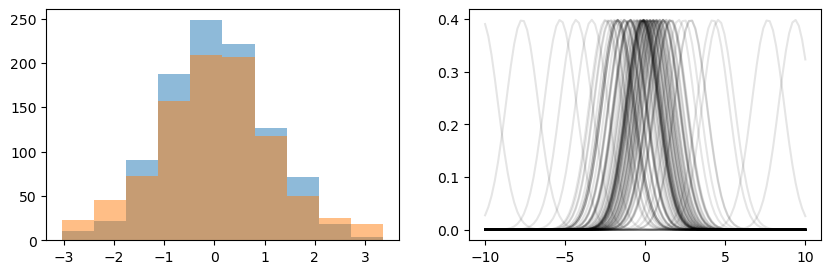

In [17]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

t = 1000
x = stats.norm().rvs(t)
y = stats.t(df=2).rvs(t)

fig,ax = plt.subplots(1,2, figsize=(10,3))
barh,bins,arts=ax[0].hist(x, alpha=0.5)
ax[0].hist(y, bins=bins, alpha=0.5)
#ax[0].set_yscale('log')

support = np.linspace(-10,10,100)
for i in range(100):
    ax[1].plot(support, stats.norm(loc=y[i],scale=1).pdf(support), 
               'k', alpha=0.1)

In [18]:
# t_df=2 samples have larger magnitude
(np.abs(y)>np.abs(x)).mean()-0.5

0.062000000000000055

In [19]:
# fraction of standarized normal > 3
(np.abs(x)>3).mean()

0.003

In [20]:
import pymc as pm

with pm.Model() as spike_and_slab:
    
    p = pm.Beta('p', alpha=1, beta=1) 
    spike = pm.Bernoulli('spike', p=p, shape=t)  # peak with probability = p
    slab = pm.Normal('slab', mu=0, sigma=100, shape=t)
    test = pm.Normal('test', mu=spike*slab, sigma=1, observed=y) 
    
    idata = pm.sample()

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [p, slab]
>BinaryGibbsMetropolis: [spike]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 205 seconds.
/opt/conda/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


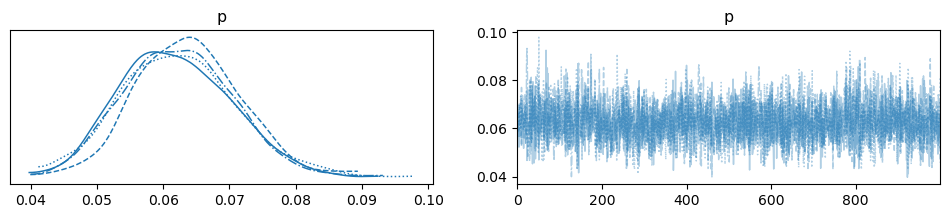

In [21]:
import arviz as az

az.plot_trace(idata, var_names='p');
# p(p|x,spike), E(p|x) = 0.0735
# whereas p(p) ~ beta, E(p) = 1/(1+1)

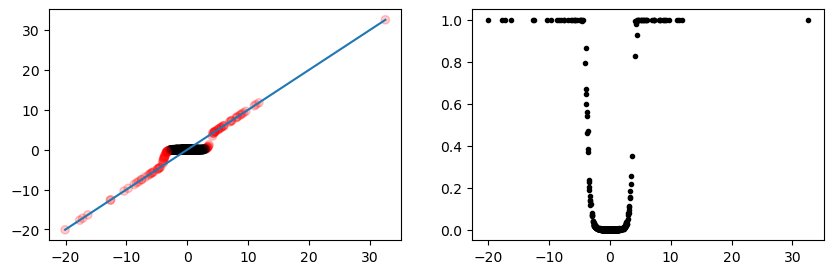

In [213]:
fig,ax = plt.subplots(1,2,figsize=(10,3))

c,d = idata.posterior['slab'].values.shape[:2]

outlier = (np.abs(y)>3)
col = ['r' if o else 'k' for o in outlier]
ax[0].plot([y.min(),y.max()], [y.min(),y.max()])
ax[0].scatter(y,
              (idata.posterior['slab'].values.reshape(c*d,t)*
               idata.posterior['spike'].values.reshape(c*d,t)).mean(axis=0),
              color=col, alpha=0.2)

ax[-1].plot(y,
            idata.posterior['spike'].values.reshape(c*d,t).mean(axis=0),'k.');

In [240]:
with pm.Model() as horseshoe:    
    
    tau_0 = 0.1  # pm.Beta('p_non0', alpha=1, beta=1) 
    tau = pm.HalfCauchy('tau', beta=tau_0, shape=1)
    lambdas = pm.HalfCauchy('lambdas', beta=1, shape=t)
    mu_ = pm.Normal('mu_', mu=0, sigma=1, shape=t)
    mu = pm.Deterministic('mu', mu_*tau*lambdas)
    test = pm.Normal('test', mu=mu, sigma=1, observed=y) # sigma: signal strength

    idata2 = pm.sample()    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, lambdas, mu_]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.
There were 735 divergences after tuning. Increase `target_accept` or reparameterize.


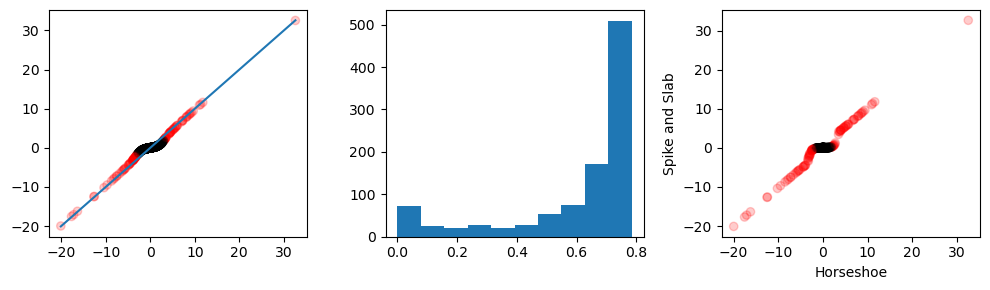

In [242]:
fig,ax = plt.subplots(1,3,figsize=(10,3))

outlier = (np.abs(y)>3)
col = ['r' if o else 'k' for o in outlier]
ax[0].plot([y.min(),y.max()], [y.min(),y.max()])
ax[0].scatter(y,
              idata2.posterior['mu'].values.reshape(c*d,t).mean(axis=0),
              color=col, alpha=0.2)

ax[1].hist(1/(1+(idata2.posterior['tau'].values*
                 idata2.posterior['lambdas'].values).reshape(c*d,t).mean(axis=0)**2));

ax[2].scatter(idata2.posterior['mu'].values.reshape(c*d,t).mean(axis=0),
              (idata.posterior['slab'].values.reshape(c*d,t)*
               idata.posterior['spike'].values.reshape(c*d,t)).mean(axis=0),
              color=col, alpha=0.2)
ax[2].set_ylabel("Spike and Slab")
ax[2].set_xlabel("Horseshoe")

plt.tight_layout()

strong signal leads to less shrinkage. 

## Bayesian Occam's Razor

$\begin{align*}
\Pr(M|x) &\propto{} \int f(x|\theta,M) p(\theta|M) p(M) d \theta\\
\Pr(M[u_i=0]|y_i) &\propto{} \int N(y_i|0,1) (1-p)^{1-u_i} p(p) dp = \int_0^1 N(y_i|0,1) (1-p) dp = \frac{1}{2}N(y_i|0,1)\\
\Pr(M[u_i=1]|y_i) &\propto{} \int\int N(y_i|\theta,1) N(\theta|0,100) p^{u_i} p(p) dp d\theta = \int N(y_i|\theta,1) N(\theta|0,100) d\theta \\
\end{align*}$

p(p) is uniform = beta(1, 1)

$u$ is spike that is Bernoulli

$\theta$ is slab

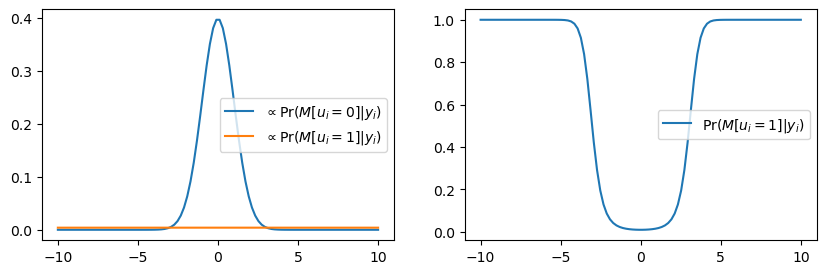

In [10]:
from scipy import integrate

def Pr_M_u_0(y):
    return stats.norm(0,1).pdf(y)

@np.vectorize
def Pr_M_u_1(y):
    return integrate.quad(lambda 𝜃: stats.norm(𝜃,1).pdf(y)*stats.norm(0,100).pdf(𝜃), 
                          -500, 500)[0]

fig,ax = plt.subplots(1,2,figsize=(10,3))

support = np.linspace(-10,10,100)
Pr_M_u_0_ = Pr_M_u_0(support)
Pr_M_u_1_ = Pr_M_u_1(support)

ax[0].plot(support, Pr_M_u_0_, label="$\\propto \\Pr(M[u_i=0]|y_i)$")
ax[0].plot(support, Pr_M_u_1_, label="$\\propto \\Pr(M[u_i=1]|y_i)$")
ax[0].legend()

ax[1].plot(support, Pr_M_u_1_/(Pr_M_u_1_+Pr_M_u_0_), label="$\\Pr(M[u_i=1]|y_i)$")
ax[1].legend();


The **Bayesian Occam's razor** phenomenon is a **curse of (parameter) dimensionality** which encourages simpler models to have larger marginal likelihoods than more complex models. We can generally expect that

$$p(\mathbf{x}|M_{\theta}) = \int f(\mathbf{x}|\theta) p(\theta)d\theta > \int\int f(\mathbf{x}|\theta, \eta) p(\theta, \eta) d\theta d\eta = p(\mathbf{x}|M_{\theta, \eta})$$

because the density of the prior $p(\theta, \eta)$ must be reduced to in relation to the increased volume in increasingly higher demensional (parameter) space.

---

Marginal likelihoods are small if
- prior specification are badly non-overlapping with the likelihood
- or if the data model cannot adequately reflect the empirical data distribution

Added model complexity that sufficiently increases likelihood to overcome the **Bayesian Occam's razor** penalization on the marginal likelihood would seem to be justified, but what of decreasing marginal likelihoods with increasing model complexity?

- The **Bayesian Occam's razor** is not a model selection tool because it depends on how well-aligned the prior is to the likelihood (data)
- What the **Bayesian Occam's razor** shows is that priors have increasingly influential effects in higher dimesions, and prior-data conflict in increasingly higher dimensions is increasingly problematic

    


## Bayes Factors

$K = \frac{p(\mathbf{x}|M_1)}{p(\mathbf{x}|M_0)} = \frac{p(M_1|\mathbf{x})}{p(M_0|\mathbf{x})} \frac{p(M_0)}{p(M_1)}$ is often proposed as a model comparison tool with evidence in favor of $M_1$ over $M_0$ given as 

|log10 K|	K|	Strength of evidence |
|-|-|-|
|0 to 1/2	|1 to 3.2	| Anecdotal|
|1/2 to 1	|3.2 to 10	| Substantial |
|1 to 2	|10 to 100 |	Strong|
|> 2|	> 100	|Decisive|
    
For fair "apples to apples" comparisons Bayes Factors might be reasonably useful.

For example, the **Savage-Dickey density ratio** for the special case where $M_1$ is a  (nested model) version of $M_0$ where the parameter value $\theta = \theta_1$ is the ratio of the **posterior** and the **prior** evaluated at $\theta=\theta_1$ 

$$
\begin{align*}
p(\mathbf{x}|M_1) ={}& \int p(\mathbf{x},\eta | M_1)d\eta\\
 ={}& \int p(\mathbf{x},\eta|\overbrace{\theta=\theta_1, M_0}^{=M_1}) d\eta = p(\mathbf{x}|\theta=\theta_1, M_0)\\
\frac{p(\mathbf{x}|M_1)}{p(\mathbf{x}|M_0)} ={}& \frac{p(\mathbf{x}|\theta=\theta_1, M_0)}{p(\mathbf{x}|M_0)} = \frac{\frac{p(\theta=\theta_1|\mathbf{x}, M_0) p(\mathbf{x}| M_0)}{p(\theta=\theta_1|M_0)}}{p(\mathbf{x}|M_0)}\\ ={}& \frac{p(\theta=\theta_1|\mathbf{x}, M_0)}{p(\theta=\theta_1|M_0)}
\end{align*}$$



## Bayesian Information Sharing

Returning to our initial variable selection considerations...

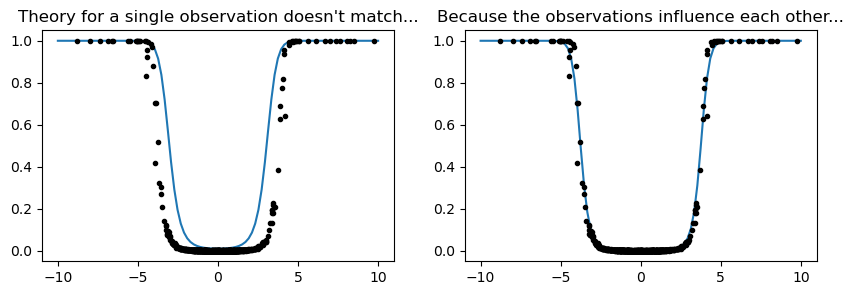

In [11]:
fig,ax = plt.subplots(1,2,figsize=(10,3))

bounds = np.abs(y)<10

ax[0].plot(support, (Pr_M_u_1_/(Pr_M_u_1_+Pr_M_u_0_)), label="$\\Pr(M[u_i=0]|y_i)$")
ax[0].plot(y[bounds],
           idata.posterior['spike'].values.reshape(c*d,t).mean(axis=0)[bounds],'k.');
ax[0].set_title("Theory for a single observation doesn't match...")

ax[1].plot(support, (.08*Pr_M_u_1_/(.08*Pr_M_u_1_+.92*Pr_M_u_0_)), label="$\\Pr(M[u_i=0]|y_i)$")
ax[1].plot(y[bounds],
           idata.posterior['spike'].values.reshape(c*d,t).mean(axis=0)[bounds],'k.');
ax[1].set_title("Because the observations influence each other...");


### Bayesian Gaussian Mixture Models 

A very simple form of information sharing...

$$\scriptsize
\begin{align*}
x_i \sim {} & \sum_{k=1}^K \mathbf{v}_{ik} \mathcal N (\mu_k,\sigma_k^2) & \mu_k \sim {} & \mathcal N (\mu_{k0},\sigma_{k0}^2) \quad \sigma_k^2 \sim \text{Inverse-Gamma} (\alpha_{k0}, \beta_{k0})\\
\overset{\overset{\text{multinomial}}{\mathbf{v}_i\,\sim\,\text{MN}}(\mathbf{p}, \,n=1)}{\Pr(\mathbf{v}_i|E[\mathbf{v}_i]=\mathbf{p}, n=1)} = {}& \frac{n!}{v_1!\cdots v_K!} p_1^{\mathbf{v}_{i1}} \cdots p_K^{\mathbf{v}_{iK}}  & \sum_{j=1}^n \mathbf{v}_{ik} = {}& 1 \quad \mathbf{v}_{ik} \in \{0,1\} \quad \text{latent (unknown) subpulation membership $\textbf{v}$} \\
\underset{\text{Dirichlet}}{\overset{p\,\sim\,\text{Dir}(\boldsymbol \alpha)}{p\left(\mathbf{p}|\boldsymbol \alpha \right)}} = {}& {\frac {1}{\mathrm {B} ({\boldsymbol {\alpha }})}}\prod _{k=1}^{K}p_{k}^{\alpha _{k}-1} & \sum_{j=1}^np_k = {}& 1 \quad {\displaystyle \mathrm {B} ({\boldsymbol {\alpha }})= \prod \limits _{k=1}^{K}\Gamma (\alpha _{k}) \bigg/ \Gamma \left(\sum \limits _{k=1}^{K}\alpha _{k}\right)} \quad E[p_k] = \alpha_k\bigg/\sum_{k=1}^K \alpha_k 
\end{align*}$$

$$\scriptsize
\begin{align*}
p(\mu_k | -) \propto {} & \mathcal N (\mu_k| \mu_{k0},\sigma_{k0}^2) \prod_{i=1}^n \sum_{k=1}^K\mathbf{v}_{ik} \mathcal N (x_i | \mu_k,\sigma_k^2) & p(\sigma_k^2 | -) \propto {} & \underset{\text{Inverse-Gamma}}{\text{IG} (\sigma_k^2|\alpha_{k0}, \beta_{k0})} \prod_{i=1}^n \sum_{k=1}^K\mathbf{v}_{ik} \mathcal N (x_i|\mu_k,\sigma_k^2)
\end{align*}$$$$\scriptsize
\begin{align*}
\Pr(\mathbf{v}_{ik}=1|-) \propto {} & p_1^{\mathbf{v}_{i1}} \cdots p_K^{\mathbf{v}_{iK}} \sum_{k=1}^K\mathbf{v}_{ik} \mathcal N (x_i | \mu_k,\sigma_k^2) & p(\mathbf{p}| - ) \propto {}& \prod _{k=1}^{K}p_{k}^{\alpha _{k}-1} \prod_{i=1}^{n} p_1^{\mathbf{v}_{i1}} \cdots p_K^{\mathbf{v}_{iK}}
\end{align*}$$

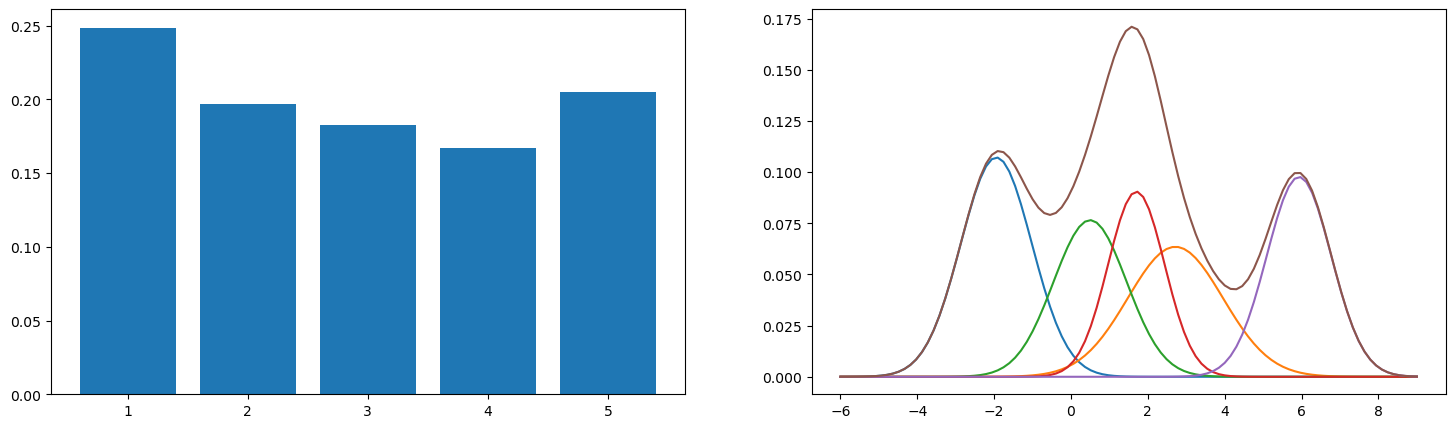

In [12]:
np.random.seed(9)

k = 5
alpha = [2]*k
p_true = stats.dirichlet(alpha).rvs(1)[0] # p_true.sum() # 1

mu_k_true = stats.norm(0,3).rvs(k)
support = np.linspace(-6,9,100)
population_pdf = 0*support
sigma2_k_true = stats.halfnorm().rvs(k)

fig,ax = plt.subplots(1,2,figsize=(18,5))
ax[0].bar(x=np.linspace(1,5,5), height=p_true)
for j in range(k):
    subpopulation_pdf = p_true[j]*stats.norm(mu_k_true[j],sigma2_k_true[j]**0.5).pdf(support)
    ax[1].plot(support, subpopulation_pdf); population_pdf += subpopulation_pdf
    
ax[1].plot(support, population_pdf); 

In [13]:
n_ = 1000
v_true = stats.multinomial(n=1,p=p_true).rvs(n_)
v_true[:3,:]

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0]])

In [14]:
print(mu_k_true)
print((v_true*mu_k_true)[:3,:])
print((v_true*mu_k_true).sum(axis=1)[:3])

[-1.94384238  2.715657    0.49645017  1.70025387  5.93193509]
[[-1.94384238  0.          0.          0.          0.        ]
 [-1.94384238  0.          0.          0.          0.        ]
 [-0.          0.          0.49645017  0.          0.        ]]
[-1.94384238 -1.94384238  0.49645017]


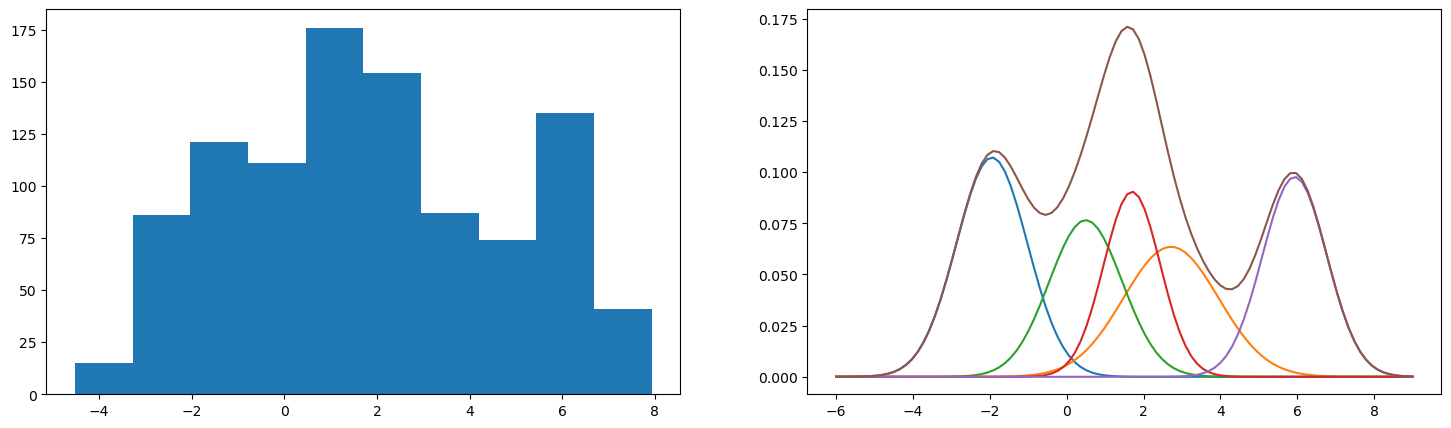

In [15]:
x_ = stats.norm((v_true*mu_k_true).sum(axis=1), (v_true*sigma2_k_true).sum(axis=1)**0.5).rvs()
ax[0].hist(x_)
fig

### Hierachical (more than random effects) Models

A more interesting form of information sharing...


In [4]:
import numpy as np
from scipy import stats
n = 100
mu = np.sort(stats.norm(0,1).rvs(n))
r = 5
# create correlated observations
y = stats.norm(mu,1).rvs((r,n))
ndx = y.astype(int)
for j in range(100):
    ndx[:,j] = j

print(np.round(np.corrcoef(y),2))

[[1.   0.64 0.57 0.52 0.56]
 [0.64 1.   0.71 0.55 0.53]
 [0.57 0.71 1.   0.52 0.56]
 [0.52 0.55 0.52 1.   0.57]
 [0.56 0.53 0.56 0.57 1.  ]]


In [17]:
# Decorrelation by within group estimation
# with independent priors
with pm.Model() as MixEff:
    
    m = pm.Normal('m', mu=0, sigma=10, shape=n)
    s = pm.HalfNormal('s', sigma=10, shape=n)
    
    x = pm.Normal('x', mu=m[ndx.flatten()], sigma=s[ndx.flatten()], 
                  observed=y.flatten())
    
    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


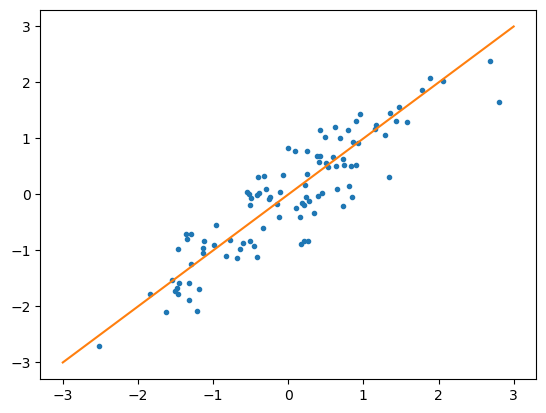

In [18]:
c,d = idata.posterior.m.shape[:2]
plt.plot(mu, idata.posterior.m.values.reshape(c*d,n).mean(axis=0), '.')
plt.plot([-3,3],[-3,3]);


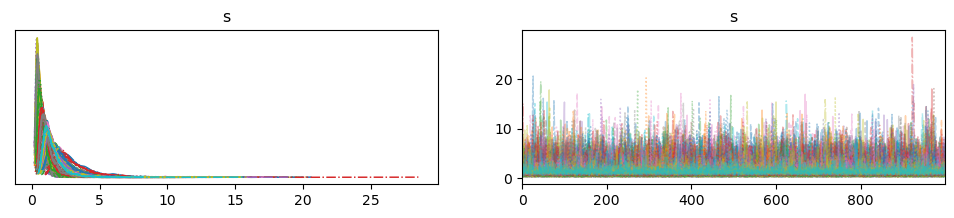

In [19]:
az.plot_trace(idata, var_names='s');

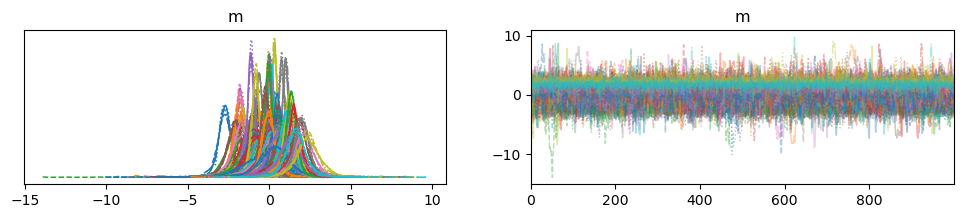

In [20]:
az.plot_trace(idata, var_names='m');

In [21]:
# Decorrelation by within group estimation
# with common hierarchical priors
with pm.Model() as MixEff2:
    
    m_s = pm.HalfNormal('m_s', sigma=10)
    m_ = pm.Normal('m_', mu=0, sigma=m_s)
    m = pm.Normal('m', mu=m_, sigma=m_s, shape=n)
    
    s_s = pm.HalfNormal('alpha', sigma=10)
    s_ = pm.HalfNormal('beta', sigma=10)
    s = pm.Gamma('s', alpha=s_s, beta=s_, shape=n)
    
    x = pm.Normal('x', mu=m[ndx.flatten()], sigma=s[ndx.flatten()],
                  observed=y.flatten())
    
    idata2 = pm.sample()


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m_s, m_, m, alpha, beta, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


0.8337212735494165 0.3061846381399181


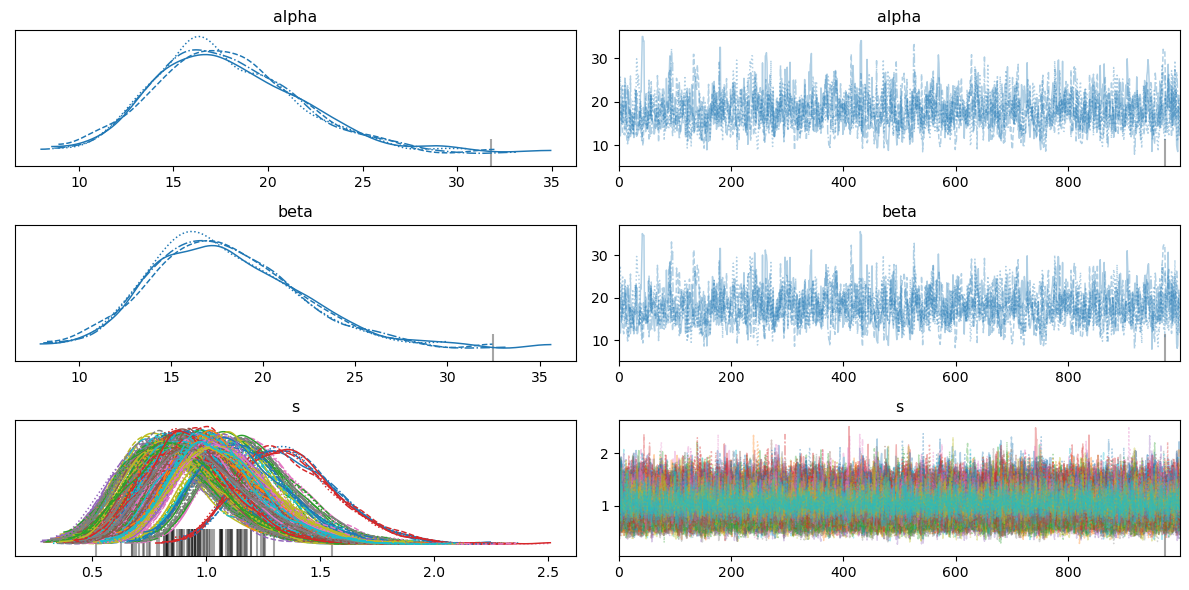

In [22]:
az.plot_trace(idata2, var_names=['alpha','beta','s'])
plt.tight_layout()
print(y.std(axis=0).mean(),y.std(axis=0).std())

-0.041950708274232425 1.0559396983972693


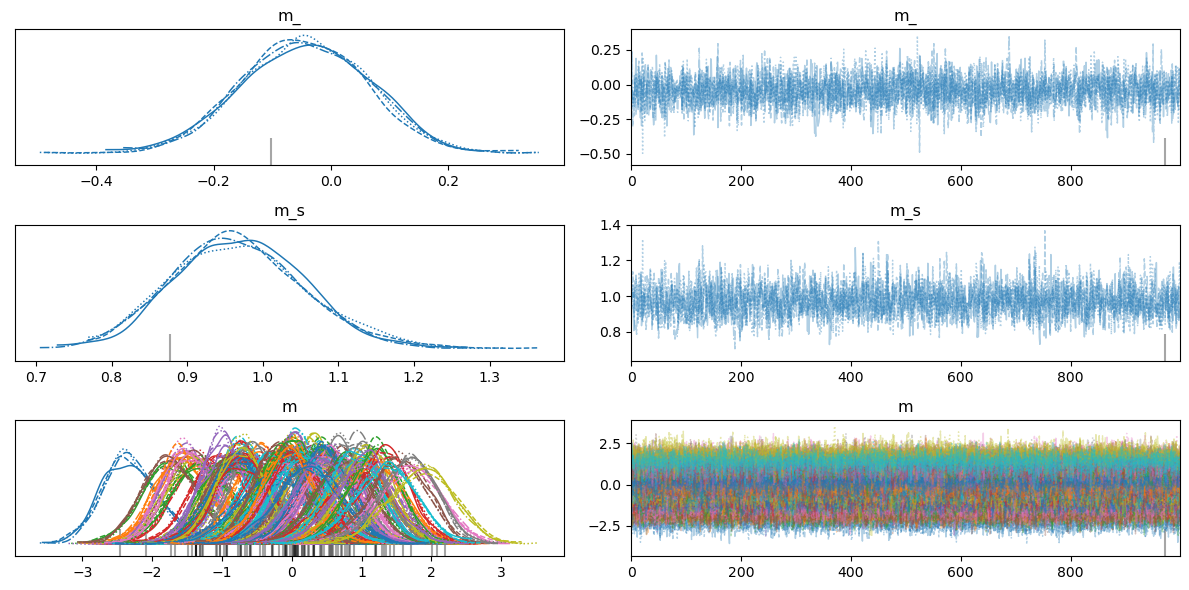

In [23]:
az.plot_trace(idata2, var_names=['m_','m_s','m'])
plt.tight_layout()
print(y.mean(axis=0).mean(),y.mean(axis=0).std())

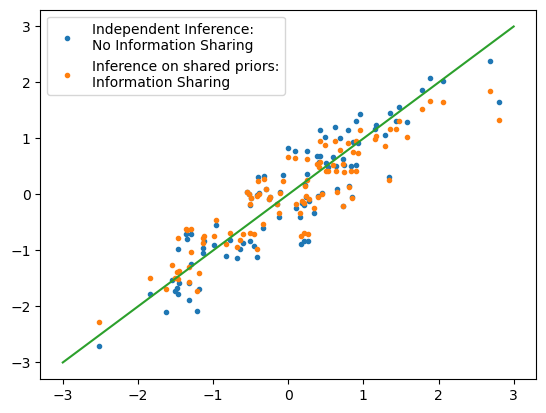

In [24]:
c,d = idata2.posterior.m.shape[:2]
plt.plot(mu, idata.posterior.m.values.reshape(c*d,n).mean(axis=0),
         '.', label="Independent Inference:\nNo Information Sharing")
plt.plot(mu, idata2.posterior.m.values.reshape(c*d,n).mean(axis=0),
         '.', label="Inference on shared priors:\nInformation Sharing")
plt.plot([-3,3],[-3,3])
plt.legend();

In [25]:
((mu-idata.posterior.m.values.reshape(c*d,n).mean(axis=0))**2).sum()**0.5         

4.6489756731397796

In [26]:
((mu-idata2.posterior.m.values.reshape(c*d,n).mean(axis=0))**2).sum()**0.5

4.490131186582001

In [27]:
# What we've learned
with pm.Model() as MixEff3:
    
    m = pm.Normal('m', mu=0, sigma=1, shape=n)
    s = pm.Gamma('s', alpha=16,beta=16, shape=n)
    
    x = pm.Normal('x', mu=m[ndx.flatten()], sigma=s[ndx.flatten()], 
                  observed=y.flatten())
    
    idata3 = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


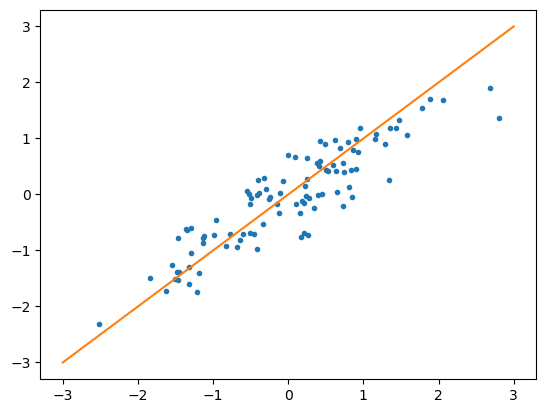

In [28]:
c,d = idata.posterior.m.shape[:2]
plt.plot(mu, idata3.posterior.m.values.reshape(c*d,n).mean(axis=0), '.')
plt.plot([-3,3],[-3,3]);


In [29]:
((mu-idata3.posterior.m.values.reshape(c*d,n).mean(axis=0))**2).sum()**0.5         

4.479632663364081

In [30]:
# Something hacky just to show more information sharing
with pm.Model() as MixEff4:
    
    m = pm.Normal('m', mu=0, sigma=1, shape=n+4)
    s = pm.Gamma('s', alpha=16,beta=16, shape=n+4)
    
    x = pm.Normal('x', mu=(m[ndx.flatten()]+m[ndx.flatten()+1]+m[ndx.flatten()+2]+m[ndx.flatten()+3]+m[ndx.flatten()+4])/5, 
                       sigma=(s[ndx.flatten()]+s[ndx.flatten()+1]+s[ndx.flatten()+2]+s[ndx.flatten()+3]+s[ndx.flatten()+4])/5, 
                  observed=y.flatten())
    
    idata4 = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


-0.041950708274232425 1.0559396983972693


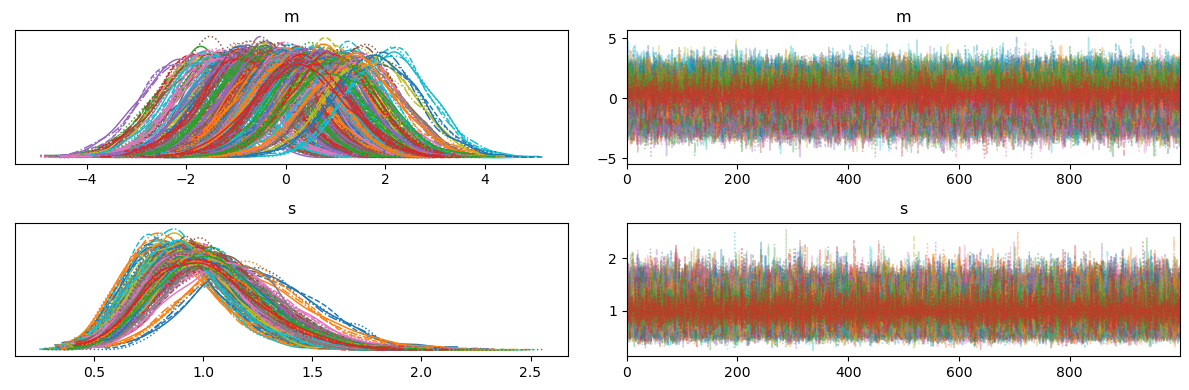

In [31]:
az.plot_trace(idata4, var_names=['m','s'])
plt.tight_layout()
print(y.mean(axis=0).mean(),y.mean(axis=0).std())

In [32]:
idata2.posterior['m'].values.reshape(c*d,n).std(axis=0)

array([0.43850059, 0.41266274, 0.44235107, 0.42245673, 0.38121094,
       0.39777552, 0.3827994 , 0.46597626, 0.42824958, 0.37989963,
       0.43638077, 0.41676165, 0.44863475, 0.41765308, 0.39870218,
       0.42931309, 0.41644588, 0.42660278, 0.42556606, 0.37703436,
       0.41096981, 0.38716467, 0.42131363, 0.3776448 , 0.40077788,
       0.40091791, 0.49585047, 0.42057879, 0.35263359, 0.43076104,
       0.41507839, 0.43531478, 0.47166267, 0.3742186 , 0.34686162,
       0.37511145, 0.39071783, 0.3594609 , 0.35018895, 0.35470342,
       0.40300339, 0.34948019, 0.45687492, 0.40587414, 0.34768134,
       0.3834457 , 0.4197695 , 0.35519866, 0.4396154 , 0.40678802,
       0.42844412, 0.43832286, 0.39224363, 0.42772299, 0.39325929,
       0.40301973, 0.43494938, 0.46694565, 0.37029808, 0.47020293,
       0.53842486, 0.40553987, 0.34626927, 0.38984609, 0.40266551,
       0.41237741, 0.45097051, 0.36544333, 0.46374771, 0.40551474,
       0.39721672, 0.43645421, 0.37155785, 0.40606803, 0.44667

In [33]:
((idata4.posterior['m'].values[:,:,:-4]+
  idata4.posterior['m'].values[:,:,1:-3]+
  idata4.posterior['m'].values[:,:,2:-2]+
  idata4.posterior['m'].values[:,:,3:-1]+
  idata4.posterior['m'].values[:,:,4:])/5).reshape(c*d,n).std(axis=0)

array([0.2998507 , 0.25845753, 0.25197178, 0.2505541 , 0.24732262,
       0.24462628, 0.24274344, 0.2421968 , 0.23850212, 0.24200233,
       0.24070933, 0.24909511, 0.24770657, 0.24141131, 0.24300796,
       0.25019407, 0.24408023, 0.23927516, 0.2420117 , 0.23634041,
       0.23433891, 0.22967199, 0.23967031, 0.23800191, 0.23638393,
       0.2462836 , 0.24820202, 0.24177675, 0.246031  , 0.24253245,
       0.24132963, 0.24068111, 0.23734873, 0.24043621, 0.24347129,
       0.2360348 , 0.23177517, 0.22898942, 0.22747222, 0.23097914,
       0.22823293, 0.23065152, 0.24011779, 0.23815895, 0.23753237,
       0.23556457, 0.2428325 , 0.24065852, 0.24067449, 0.24129952,
       0.24434271, 0.24141474, 0.24658071, 0.24350512, 0.24032138,
       0.24462945, 0.24810307, 0.25564213, 0.25444123, 0.25173322,
       0.25497645, 0.24771738, 0.24534431, 0.24278456, 0.24196904,
       0.24337037, 0.24531718, 0.24318762, 0.24316551, 0.24152387,
       0.2433567 , 0.24714464, 0.24573133, 0.24244391, 0.24209

In [34]:
mmm = \
((idata4.posterior['m'].values[:,:,:-4]+
  idata4.posterior['m'].values[:,:,1:-3]+
  idata4.posterior['m'].values[:,:,2:-2]+
  idata4.posterior['m'].values[:,:,3:-1]+
  idata4.posterior['m'].values[:,:,4:])/5).reshape(c*d,n).mean(axis=0)

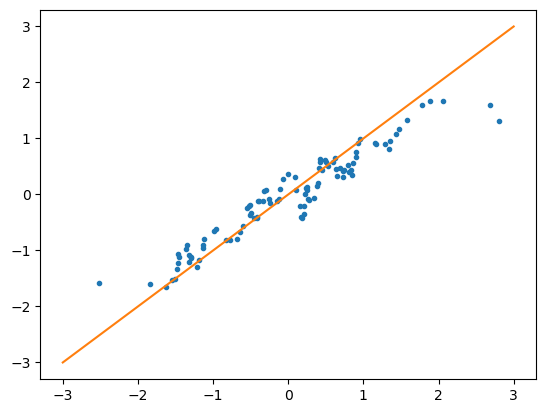

In [35]:
c,d = idata.posterior.m.shape[:2]
plt.plot(mu, mmm, '.')
plt.plot([-3,3],[-3,3]);


In [36]:
((mu-mmm)**2).sum()**0.5

3.3781931084511476

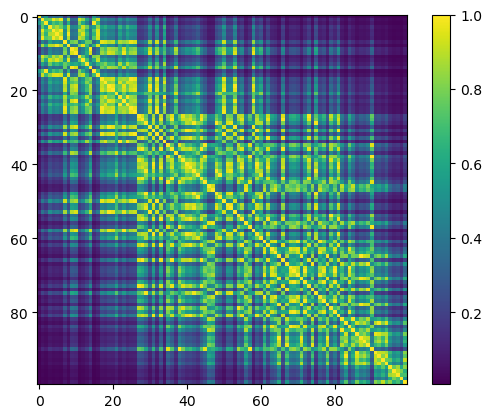

In [53]:
_lambda = .06
sigma2 = 1
K = sigma2*np.exp(-(y.mean(axis=0).reshape(n,1) - 
                    y.mean(axis=0).reshape(1,n))**2/_lambda**2)

alf = 1
K = sigma2*np.exp(-alf*np.abs(y.mean(axis=0).reshape(n,1) - 
                              y.mean(axis=0).reshape(1,n)))

K=(K+K.T)/2  # np.linalg.matrix_rank(K)
plt.imshow(K)
plt.colorbar();

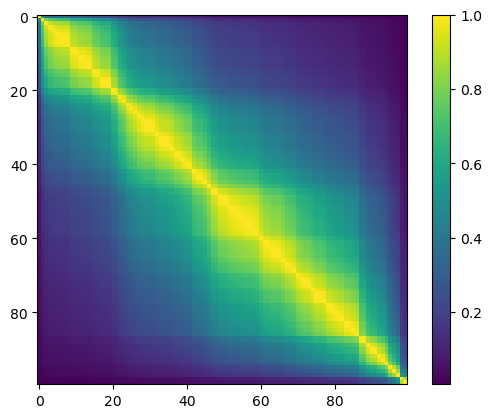

In [77]:
K = sigma2*np.exp(-alf*np.abs(mu.reshape(n,1) - 
                              mu.reshape(1,n)))
K=(K+K.T)/2  # np.linalg.matrix_rank(K)
plt.imshow(K)
plt.colorbar();

In [78]:
# What we've learned
with pm.Model() as MixEff5:
    
    m = pm.MvNormal('m', mu=0, cov=K, initval=y.mean(axis=0))
    s = pm.Gamma('s', alpha=16, beta=16, shape=n)    
    x = pm.Normal('x', mu=m[ndx.flatten()], sigma=s[ndx.flatten()], 
                  observed=y.flatten())
    
    idata5 = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


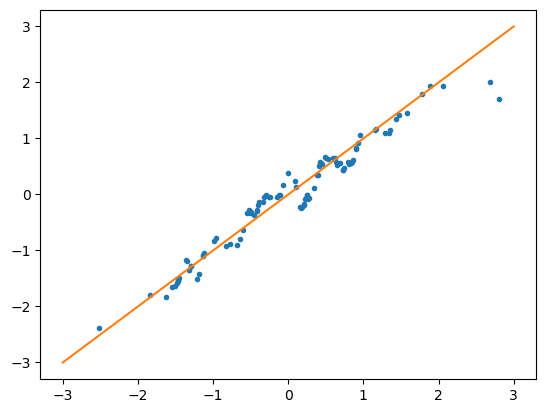

In [79]:
c,d = idata.posterior.m.shape[:2]
plt.plot(mu, idata5.posterior.m.values.reshape(c*d,n).mean(axis=0), '.')
plt.plot([-3,3],[-3,3]);


-0.041950708274232425 1.0559396983972693


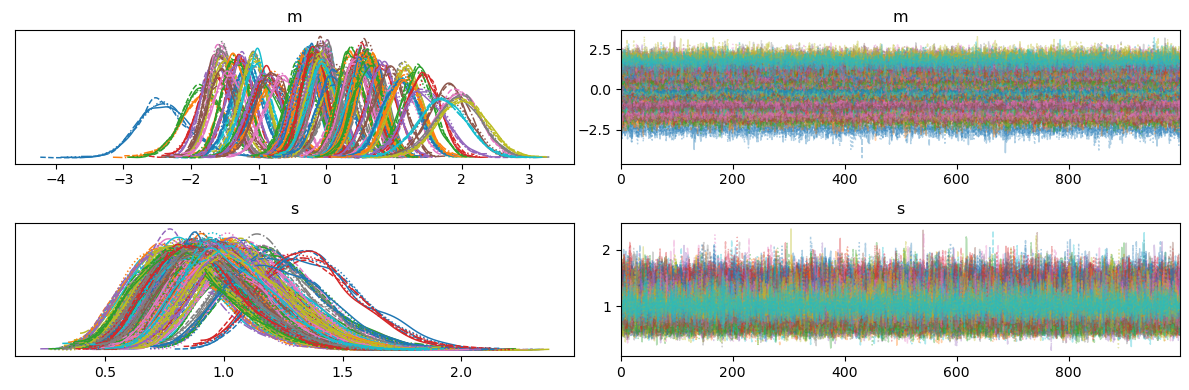

In [80]:
az.plot_trace(idata5, var_names=['m','s'])
plt.tight_layout()
print(y.mean(axis=0).mean(),y.mean(axis=0).std())

In [81]:
((mu-idata5.posterior.m.values.reshape(c*d,n).mean(axis=0))**2).sum()**0.5         

2.3275729832477094

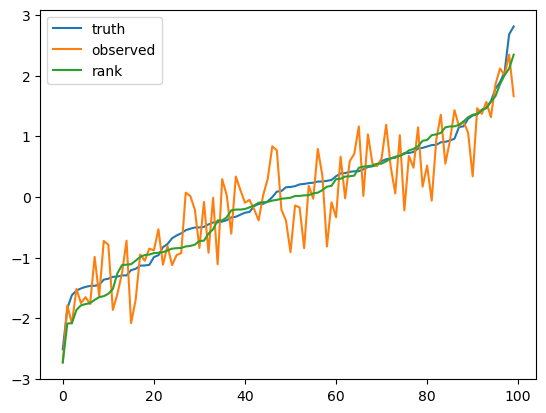

In [82]:
plt.plot(mu, label="truth")
plt.plot(y.mean(axis=0), label="observed")
plt.plot(np.sort(y.mean(axis=0)), label="rank")
plt.legend();

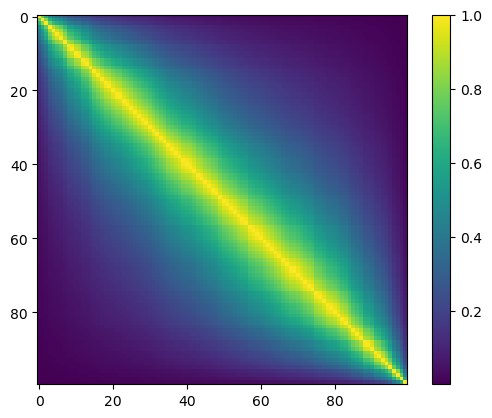

In [83]:
K = sigma2*np.exp(-alf*np.abs(np.sort(y).mean(axis=0).reshape(n,1) - 
                              np.sort(y).mean(axis=0).reshape(1,n)))

K=(K+K.T)/2  # np.linalg.matrix_rank(K)
plt.imshow(K)
plt.colorbar();

In [84]:
# What we've learned
with pm.Model() as MixEff6:
    
    m = pm.MvNormal('m', mu=0, cov=K, initval=y.mean(axis=0))
    s = pm.Gamma('s', alpha=16, beta=16, shape=n)    
    x = pm.Normal('x', mu=m[ndx.flatten()], sigma=s[ndx.flatten()], 
                  observed=y[:,np.argsort(y.mean(axis=0))].flatten())
    
    idata6 = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


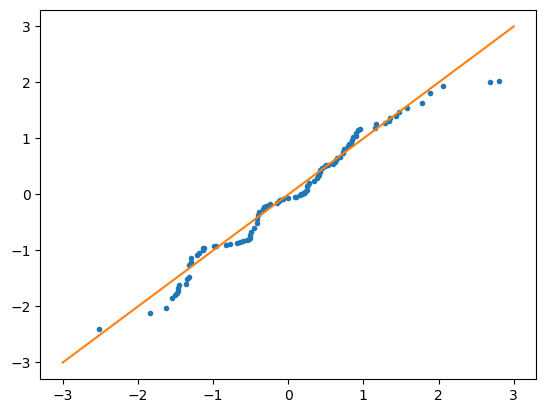

In [85]:
c,d = idata.posterior.m.shape[:2]
plt.plot(mu, idata6.posterior.m.values.reshape(c*d,n).mean(axis=0), '.')
plt.plot([-3,3],[-3,3]);


In [86]:
((mu-idata6.posterior.m.values.reshape(c*d,n).mean(axis=0))**2).sum()**0.5         

1.7571074861272944

## Back to Model Selection

### LRT

The **(nested) log likelihood ratio test (LRT) statistic** is $\quad2\log\left(\frac{p(y|\hat \theta_{M_1})}{p(y|\hat \theta_{M_0)}}\right) = \color{gray}{2(\log(p(y|\hat \theta_{M_1})) - \log(p(y|\hat \theta_{M_0})))} $ 

and has an asymptotically $\;\chi^2_{df}\;$ distribution with **expected value** [equal](https://en.wikipedia.org/wiki/Likelihood-ratio_test) **degrees of freedom**  $\dim(\theta_{M_1})-\dim(\theta_{M_0})$

$$2\log\left(\frac{p(y|X_{n\times p}\hat \beta)}{p(y|\bar y)}\right)\quad \text{is asymptotically} \;\;\chi^2_{p-1}\;\;\text{and a large LRT statistic rejects $M_0$ in favor of $M_1$} $$

> #### Sketch of Some "Intuition" as to Why this is so
> 
> - $p(y|\hat \theta_{M})$ is assymptotically normal 
> - $\frac{p(y|\hat \theta_{M_1})}{p(y|\hat \theta_{M_0})}$ cancels normalizing constants
> - $\log p(y|\hat \theta_{M})$ after canceling normalizing constants, and since one parameter $\theta_i$ perfectly predicts one $\theta_i=y_i$, is $-\frac{1}{2}\sum_{i=1}^{n-\text{dim}(M)+1} \frac{(y_i-\bar y)^2}{\sigma^2} -\frac{1}{2}\sum_{i=1}^{\text{dim}(M)-1} \frac{(y_j-y_j)^2}{\sigma^2}$
> - $E[\frac{(y_i-\bar y)^2}{\sigma^2}] = 1$ so the $-\frac{1}{2}$ term makes difference $\text{dim}(M)-1$ and cancels the scaling $2$

### Deviance  and "Bayesian" Model Size

Model **deviance** is $\quad D(\theta) = 2(\underset{\text{a constant}}{\overset{\text{saturated model}}{\log(p(y|y))}} - \overset{\text{actual model}}{\log(p(y|\theta)})) \color{gray}{= 2\log\left(\frac{p(y|y)}{p(y|\theta)}\right)} \geq 0 \quad$ (scaled by $2$ [to match the LR](https://stats.stackexchange.com/qu,estions/379810/why-is-the-deviance-defined-with-a-factor-2-or-likelihood-ratio-squared))

The [Bayesian characterization](https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=d78ad2497639bff740d0c1181c35263d2630b172)
 of the **effective number of parameters** in a model is

$$p_D = {\overline{D(\theta)} - D(\bar{\theta})} \color{gray}{= 2(\log(p(y|\bar{\theta})) - \overline{\log(p(y|\theta))}) \underset{\text{usually}}{\geq 0}} \quad \text{ or } \quad \underset{\text{not typically preferred as it's less stable}}{p_D = 2\text{Var}_{p(\theta|y)}[\log(p(y|\theta))]}$$

because (for fixed models such as ["linear models with uniform prior distributions"](http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf) and large $n$) both versions of $p_D$ estimate the degrees of freedom parameter of the asymptotic $\chi^2_{\text{df}}$ of $\log(p(y|\theta))$ which is the number of parameters $p(y|\theta)$.

> #### Sketch of the "Proof" as to Why this is so
> 
> $-2\log(p(y|\bar{\theta})$ for linear regression is the expected standardized residual sum of squares
> 
> $\begin{align*}
(y-\hat y)^T(y-\hat y)/\sigma^2 &={} y^T(I-H)^T(I-H)y/\sigma^2
= y^T(I-H)(I-H)y/\sigma^2 
= y^T(I-H)y/\sigma^2 \\
&={} (X\beta + \epsilon)^T(I-H)(X\beta + \epsilon)/\sigma^2
= \epsilon^T(I-H)\epsilon/\sigma^2 = \text{trace}(\epsilon^T(I-H)\epsilon/\sigma^2)\\
&={} \text{trace}((I-H)\epsilon\epsilon^T/\sigma^2) = \text{trace}((I-H)\epsilon\epsilon^T/\sigma^2) \\
\text{with expected value} & \quad \; \text{trace}((I-H)\sigma^2I/\sigma^2) = \text{trace}(I-H) = n - \text{trace}(H)\\
&={} n - \text{trace}(X^T(X^TX)^{-1}X) = n - \text{trace}((X^TX)^{-1}XX^T) = n - \text{trace}(I_{p \times p})\\
&={} n - p
\end{align*}$
>
> while $-2\overline{\log(p(y|\theta))}$ does something like reflect the variability of $n-p$ unexplained data points plus the variability of $p$ parameters 
> $E_{\hat y}[\sum_{i=1}^n \frac{(y_i - \hat y_i)^2}{\sigma^2} ] \overset{\text{if unbiased}}{\approx} E_{\hat y}[\sum_{i=1}^n \frac{(y_i - E[y_i])^2}{\sigma^2} ]$ which has an expected value (with respect to $y$) of $n$.

### Information Criterion

**Information Criterion** criterion refer to the fact that each additional parameter is expected to decrease $-2\log f(y | \theta)$ by $1$ unit, where a lower negative loglikelihood is "better". 

Rearranging $\;\;p_D = {\overline{D(\theta)} - D(\bar{\theta})}\;\;$ in terms of **posterior mean deviance** $\;\;\overline{D(\theta)} = D(\bar{\theta}) + p_D\;\;$ leads to the ["adequacy" "measure of fit plus complexity"](https://fisher.stats.uwo.ca/faculty/aim/2015/9938/articles/SpiegelhalterJRSSB2002.pdf) **deviance information criterion** in the standard **information criterion form**

\begin{align*}
\text{DIC:} \;{}& -2\log(p(y|\bar{\theta})) + 2p_D \quad\;\;\text{since} \quad \overline{D(\theta)}+p_D = D(\bar{\theta}) + 2p_D \quad \text{$p(y|y)$'s cancel in DIC$_{M_1}$-DIC$_{M_0}$}\\
\text{AIC:} \;{}& -2\log(p(y|\hat{\theta})) + 2p \quad\quad\, \text{and $\quad e^{(\text{AIC$_{M_0}$-AIC$_{M_1}$})/2}\quad$ is an unnested version of the }\textbf{LRT statistic}\\
\text{BIC:} \;{}& -2\log(p(y|\hat{\theta})) + p\ln(n) \;\;\, \text{which approximates }\textbf{Bayes Factor} K = \frac{p(\mathbf{x}|M_1)}{p(\mathbf{x}|M_0)} \approx e^{(BIC_{M_0}-BIC_{M_1})/2}
\end{align*}

### Out of sample predictive performance 

Recall that **Bayes factors** induce an **Occam's razor** (parameter integration dimension) penalization for model complexity; whereas, **DIC** and [**AIC**](https://stats.stackexchange.com/questions/116935/comparing-non-nested-models-with-aic) measure ["out-of-sample-prediction error using a bias-corrected adjustment of within-sample error"](http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf) 

Even though the **Bayesian Occam's razor** (with **Bayes factors**) naturally favoring parsimony in model selection is intuitively attractive, this "simplest solution is the best solution" perspective is not necessarily always justified.

- It is still reasonable to prefer more complex models with improved out of sample performance 

**Machine learning $K$-folds cross-validation parameter tuning** optimizes the *bias-variance tradeoff** in a model fit which allows the model to be both underfit and overfit in different areas of the prediction space and so improves the overall out of sample predictive accuracy by reducing bias in critical areas while inducing minimal "collatoral damage" from overfitting in other areas.

- **Bayesian Occam's razor** (with **Bayes factors**) does not attempt to optimize the **bias-variance tradeoff** in this "overfitting" manner; rather, it penalizes "prior misspecifications" that are increasingly unavoidable in higher dimensions and can rapidly overwhelm the potential beneficial increases in model flexibility observable in the likelihood. 


### Widely Applicable Information Criterion (WAIC)<br> and Leave-One-Out Cross Validation (LOO-CV) 

- ***BIC:*** $\;-2\log(p(y|\hat{\theta})) + p \ln(n)\;$ is based on approximating ***Bayes factors***
    - but it's not actualy a **Bayesian** method since it doesn't integrate over the **posterior uncertainty**
- **DIC:** $\;-2\log(p(y|\bar{\theta})) + 2p_D\;$ is similarly not **fully Bayesian**
    - since $p_D \color{gray}{= {\overline{D(\theta)} - D(\bar{\theta})}} = \color{navy}{2(\log(p(y|\bar{\theta})) - \overline{\log(p(y|\theta))})}$ 
    - **conditions** on the **posterior mean** $\bar{\theta}$ rather than integrating over the **posterior uncertainty**(!)
    - The alternative $\color{purple}{\;p_D = 2\text{Var}_{p(\theta|y)}[\log(p(y|\theta))]\;}$ was unstable but it was **fully Bayesian**...

**WAIC** uses the **log pointwise predictive density** $llpd = \log\left(\prod_{i=1}^n p(y_i|\theta)\right)$ to estimate **effective model size** as

$$\color{purple}{\;p_{\text{WAIC2}} = \sum_{i=1}^n\text{Var}_{p(\theta|y)}[\log(p(y_i|\theta))]\quad \color{gray}{\text{(although note there's no longer a factor of $2$ [proof not shown])}}}$$
which provide stable estimation, and is preferred over the (also **fully Bayeisan**) $$\;\color{navy}{p_{\text{WAIC1}} = 2\sum_{i=1}^n\left(\log\left( \frac{1}{T}\sum_{t=1}^T p(y_i|\theta^{(t)}) \right) - \frac{1}{T}\sum_{t=1}^T\log(p(y_i|\theta^{(t)}))\right)\;}$$ because $p_{\text{WAIC2}}$ <u>is theoretically and empirically more similar to a **LOO-CV**</u> calculation than $p_{\text{WAIC1}}$ <font style='color:gray'></font>


The above **information criterion** can now be extended with 

$\quad\quad\text{WAIC:} \;-2\sum_{i=1}^n\left(\log\overline{p(y_i|\theta)}\right) + 2p_{\text{WAIC2}} =  -2\sum_{i=1}^n\left(\log\left( \frac{1}{T}\sum_{t=1}^T p(y_i|\theta^{(t)}) \right)\right) + 2p_{\text{WAIC2}}$

---

The difference bewteen **WAIC** and **DIC** is that **WAIC** fully integrates over the posterior while **DIC** does not and instead conditions on the **posterior parameter mean**

- They both are "more Bayesian" than the **AIC** in incorporate the **prior** into **effective model size** estimation
- and in the same way both are "more Bayesian" than the **BIC** even though it approximates **Bayes factors**

> <font style='color:navy'>And anyway remember that **BIC** does not estimate ["out-of-sample-prediction error using a bias-corrected adjustment of within-sample error"](http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf)</font>


But ***WAIC*** is just a computationally tractable alternative to  
***bias corrected <u>log pointwise predictive density</u> $lppd$ Leave-One-Out Cross Validation (LOO-CV)***

$$\overset{\text{corrected}}{lppd_{loo-cv}}=\sum_{i=1}^n\log \underbrace{\left(\frac{1}{T}\sum_{t=1}^T p(y_i|\theta^{(t|-i)})\right)}_{\theta^{(t|-i)} \sim p(\theta|y_{-i})} + \underset{\text{due to using $n-1$ not $n$}}{\underbrace{lppd-\overline{lppd^{(-i)}}}_{\text{underestimated accuracy}}}$$

with ***AIC***, ***DIC*** and ***WAIC*** are asymptotically equivalent to ***log pointwise predictive density LOO-CV*** under various conditions...


## Week 11 Homework (9)

### Q1: copulas

1. Use the example copula code below to provide posterior inference on the dependency structure between for **your own non normally distributed data that you find** 
2. Repeat the exercise using instead a two pass approach in the manner of https://www.pymc.io/projects/examples/en/latest/howto/copula-estimation.html
3. Describe what a copula is and how the two verions of code implement it 
4. Describe how to use this to create arbitrary multivariate GLM regressions

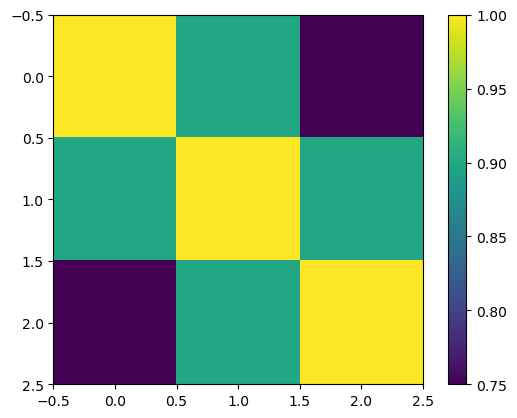

In [89]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

p = 3
#Psi = np.eye(p)
#a_cov = stats.invwishart(df=p+2, scale=Psi).rvs()
a_cor = (np.ones((p,p))*9+np.diag((1,1,1)))/10
a_cor[0,-1] -= 0.15
a_cor[-1,0] -= 0.15

n = 100
x = stats.multivariate_normal(mean=np.zeros(p), cov=a_cor).rvs(size=n)
plt.imshow(a_cor)
plt.colorbar();


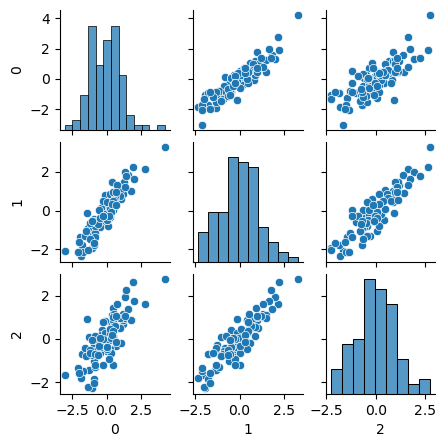

In [90]:
import seaborn
import pandas as pd
seaborn.pairplot(pd.DataFrame(x),height=1.5);

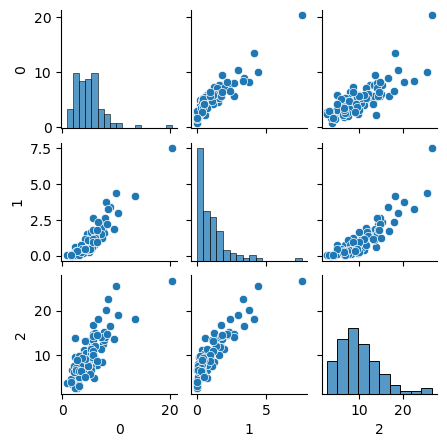

In [91]:
y = x.copy()
y[:,0] = stats.gamma(a=5).ppf(stats.norm().cdf(x[:,0]))
y[:,1] = stats.expon(scale=1).ppf(stats.norm().cdf(x[:,1]))
y[:,2] = stats.chi2(df=10).ppf(stats.norm().cdf(x[:,2]))

seaborn.pairplot(pd.DataFrame(y),height=1.5);

In [129]:
import pymc as pm
import arviz as az

with pm.Model() as copula:

    p0 = pm.HalfNormal('p0', sigma=10)
    y0 = pm.Gamma('y0', alpha=p0, beta=1, observed=y[:,0:1])
    y0_ = pm.Deterministic('y0_', 
            pm.Normal.icdf(
               pm.math.exp(pm.Gamma.logcdf(y0, alpha=p0, inv_beta=1)), 
                           mu=0, sigma=1))
    
    p1 = pm.HalfNormal('p1', sigma=10)
    y1 = pm.Exponential('y1', lam=p1, observed=y[:,1:2])
    y1_ = pm.Deterministic('y1_', 
            pm.Normal.icdf(
               pm.math.exp(pm.Exponential.logcdf(y1, mu=p1)), 
                           mu=0, sigma=1))

    p2 = pm.HalfNormal('p2', sigma=10)
    y2 = pm.ChiSquared('y2', nu=p2, observed=y[:,2:3])
    y2_ = pm.Deterministic('y2_', 
            pm.Normal.icdf(
               pm.math.exp(pm.ChiSquared.logcdf(y2, nu=p2)), 
                           mu=0, sigma=1))
    
    L,R,stds = pm.LKJCholeskyCov("R", n=3, eta=2.0, 
                                 sd_dist=pm.Exponential.dist(1.0, shape=3), 
                                 compute_corr=True)
    
    potential = pm.Potential("MVNeval", 
                             pm.logp(pm.MvNormal.dist(mu=0, cov=R),
                             pm.math.concatenate([y0_,y1_,y2_], axis=1)))
    
    idata = pm.sample()

# This probally produces a lot of warnings but it will run and provide inference


<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

...

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Matrix(bool, shape=(1, 1))) must be compatible with the type of the original Variable (Matrix(bool, shape=(100, 1))). local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_useless_elemwise
ERROR (pytensor.graph.rewriting.basic): node: And(Lt.0, [[False] ... [False]])
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1960, in process_node
    fgraph.replace_all_validate_remove(  # type: ignore
  File "/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/graph/features.py", line 626, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p0, p1, p2, R]


/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
  warn(
/Users/scottschwartz/miniconda3/envs/PyMC/lib/python3.11/site-packages/pytensor/tensor/rewriting/elemwise.py:691: UserWarning: Optimization Warning: The Op erfcinv does not

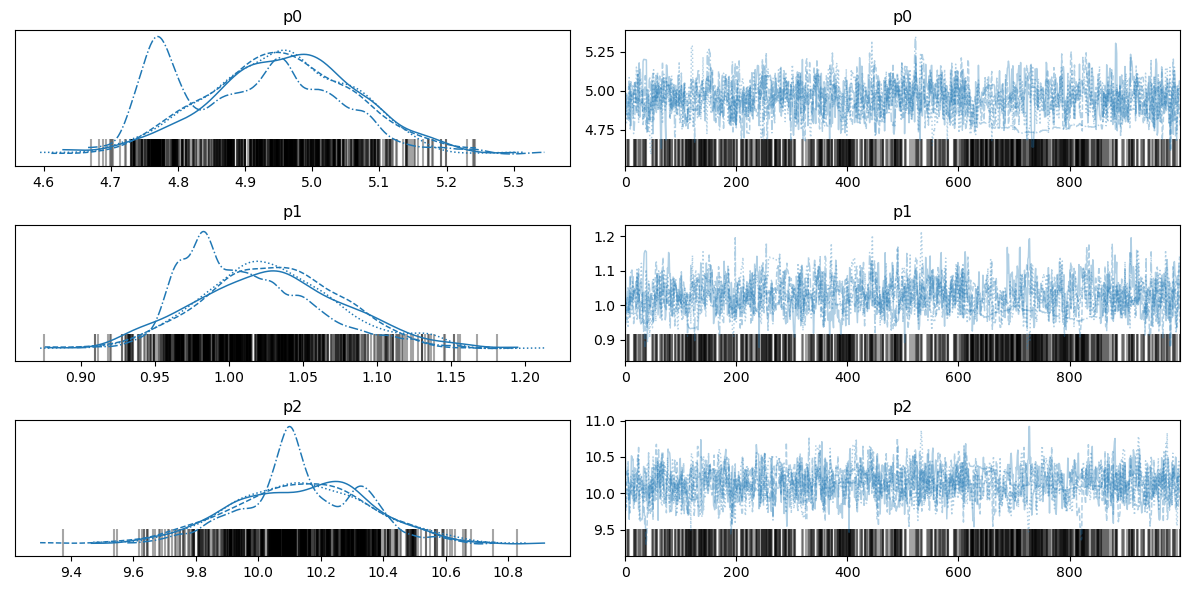

In [134]:
# Estimation is essentially correct
az.plot_trace(idata, var_names=['p0','p1','p2'])
plt.tight_layout()

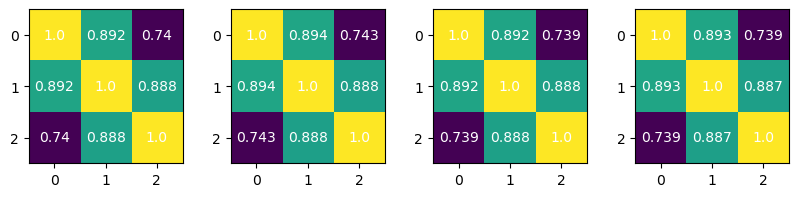

In [154]:
# Estimation is essentially correct
fig,ax = plt.subplots(1,4,figsize=(10,2))
for i,c in enumerate(list(idata.posterior['R_corr'].values.mean(axis=1))):
    ax[i].imshow(c)
    for k in range(3):
        for j in range(3):
            ax[i].text(j,k,s=str(round(c[j,k],3)), 
                       color='w', va='center', ha='center')

## Q1.2

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt

In [3]:
data_d = pd.read_csv('measures_v2.csv').head(100)
print(data_d.head())

X = data_d[['motor_speed']].values
Y = data_d[['pm']].values

X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)

a = ((X - X_mean) / X_std).flatten()
b = Y.flatten()


        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172       19.086670 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571       19.092390 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770       19.089380 -0.372503     18.294094     0.002355   
3 -0.327026  18.835567       19.083031 -0.316199     18.292542     0.006105   
4 -0.471150  18.857033       19.082525 -0.332272     18.291428     0.003133   

        i_d       i_q         pm  stator_yoke    ambient    torque  profile_id  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101          17  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417          17  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615          17  
3  0.000026  0.002046  24.554018    18.330833  19.850647  0.238303          17  
4 -0.064317  0.037184  24.565397    18.326662  19.850639  0.208197          17  


In [6]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns

from scipy.stats import expon, multivariate_normal, norm

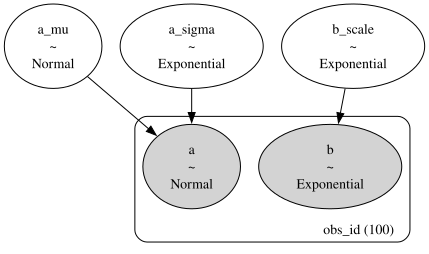

In [4]:
n = len(a)
coords = {"obs_id": np.arange(len(a))}
with pm.Model(coords=coords) as marginal_model:
    a_mu = pm.Normal("a_mu", mu=0, sigma=1)
    a_sigma = pm.Exponential("a_sigma", lam=0.5)     
    pm.Normal("a", mu = a_mu, sigma = a_sigma, observed=a, dims="obs_id")

    b_scale = pm.Exponential("b_scale", lam=0.5)
    pm.Exponential("b", lam=1 / b_scale, observed=b, dims="obs_id")
pm.model_graph.model_to_graphviz(marginal_model)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a_mu, a_sigma, b_scale]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


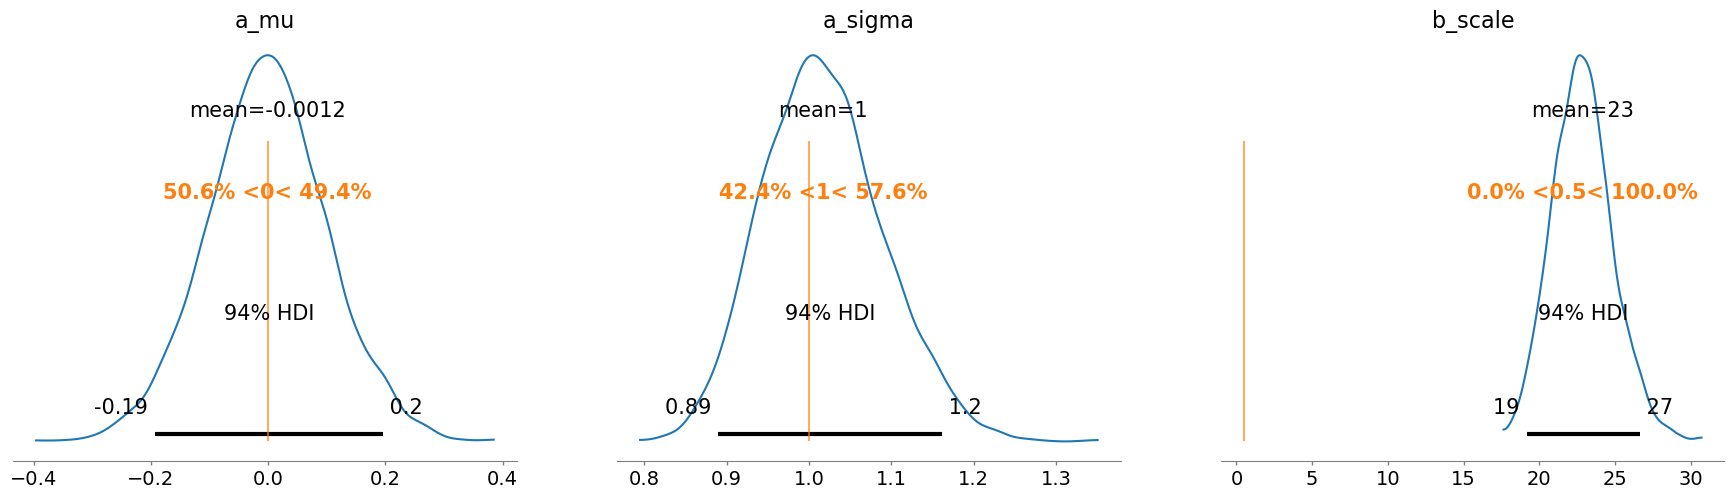

In [7]:
rng = np.random.default_rng(43)
with marginal_model:
    marginal_idata = pm.sample(random_seed=rng)
az.plot_posterior(
    marginal_idata, var_names=["a_mu", "a_sigma", "b_scale"], ref_val=[0, 1.0, 1 / 2.0]
);

In [8]:
def transform_data(marginal_idata):
    # point estimates
    a_mu = marginal_idata.posterior["a_mu"].mean().item()
    a_sigma = marginal_idata.posterior["a_sigma"].mean().item()
    b_scale = marginal_idata.posterior["b_scale"].mean().item()
    # transformations from observation space -> uniform space
    __a = pt.exp(pm.logcdf(pm.Normal.dist(mu=a_mu, sigma=a_sigma), a))
    __b = pt.exp(pm.logcdf(pm.Exponential.dist(lam=1 / b_scale), b))
    # uniform space -> multivariate normal space
    _a = pm.math.probit(__a)
    _b = pm.math.probit(__b)
    # join into an Nx2 matrix
    data = pt.math.stack([_a, _b], axis=1).eval()
    return data, a_mu, a_sigma, b_scale


data, a_mu, a_sigma, b_scale = transform_data(marginal_idata)

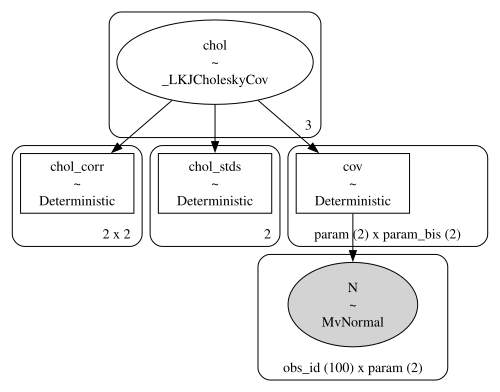

In [9]:
coords.update({"param": ["a", "b"], "param_bis": ["a", "b"]})
with pm.Model(coords=coords) as copula_model:
    # Prior on covariance of the multivariate normal
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol",
        n=2,
        eta=2.0,
        sd_dist=pm.Exponential.dist(1.0),
        compute_corr=True,
    )
    cov = pm.Deterministic("cov", chol.dot(chol.T), dims=("param", "param_bis"))

    # Likelihood function
    pm.MvNormal("N", mu=0.0, cov=cov, observed=data, dims=("obs_id", "param"))

pm.model_graph.model_to_graphviz(copula_model)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [chol]


Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 25 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


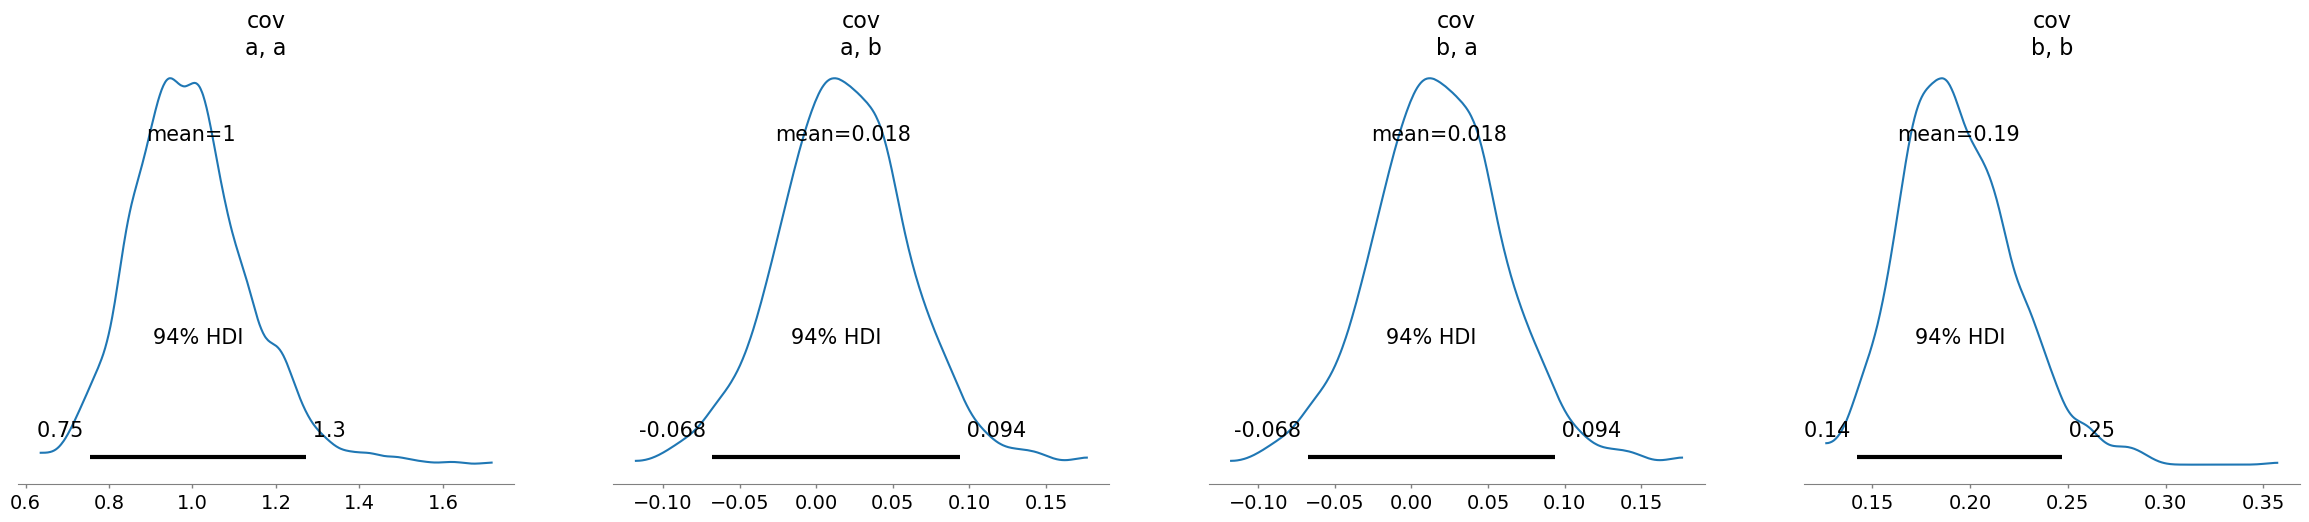

In [10]:
with copula_model:
    copula_idata = pm.sample(random_seed=rng, tune=2000, cores=1)

az.plot_posterior(copula_idata, var_names=["cov"]);

Here are the distributions of estimated covariance between non-normal variable "motor speed" and non-normal variable "pm". Motor speed is standardized, so the result shows the variance of this variable is centered at 1. 

## Q1.3

A copula is a statistical tool used to model and analyze the dependence structure between random variables by separating the marginal distributions from the joint distribution. Given variables $X_1, X_2,...$ and their marginal CDF functions $F_1, F_2, ...$, a copula C combines these marginal CDF functions to get an overall CDF functions: $F(X_1, X_2, ...) = C(F_1(X_1), F_2(X_2), ...)$

For the exampled codes, a multivariate normal distribution x is generated with a given covariance structure. Then, each component of x is transformed into uniform marginal and then into observation space via Gamma, Exponential, and Chi-squared. In this space, PYMC is used to sample the covariance structure. The transformed variables are assumed to follow a multivariate normal distribution with correlation matrix R. Then, the posterior distribution of covariance R is shown. 

In my code, I start from observation space. I assume X is from the normal distribution and Y is from the exponential distribution. I transfer the data from observation space to uniform space and then transfer to multivariate normal space. In this space, I use a prior that the transfered data form a multivariate normal distribution and sample covariance based on this prior. 

## Q1.4

To perform multivariate GLM regressions with copulas, we can first fit GLMs to each outcome variable independently and obtain residuals from each model. Then, we can use the copula to model the dependence structure between the residuals. This step captures correlations and dependencies that are not explained by the GLMs themselves. We can predict joint outcomes by combining the marginal predictions with the copula.

### Q2: Variable Selection using Spike and Slab

Perform multivarite regression (or multivariate probit classification) with spike and slab variable selection priors and compare inference to analagous inference with diffuse normal priors (imposing minimal L2 style regularization on the likelihood).

You may artificially limit the size of your data to reduce the computational demands, but if you do so, discuss the behavior of the computational demands with respect to the number of observations $n$, the number of random variables $m$ making up the multivariate observations, and the number of columns of the design matrix $p$.



The computational cost is influenced by:

Number of Observations (n): The complexity grows approximately linearly with n, as each sample needs to be processed.

Number of Predictors (p): The spike-and-slab model introduces binary inclusion variables for each predictor, increasing complexity exponentially as p grows.

Number of Responses (m): Complexity scales with the joint distribution of m responses, making it grow as $O(m^2)$ for multivariate modeling.

In [2]:
data_d = pd.read_csv('measures_v2.csv').head(100)
print(data_d.head())

X = data_d[['motor_speed']].values
Y = data_d[['pm', 'stator_tooth']].values

X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)
X_standardized = (X - X_mean) / X_std

n, p = X.shape
m = Y.shape[1]
print(n,p,m)

        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172       19.086670 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571       19.092390 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770       19.089380 -0.372503     18.294094     0.002355   
3 -0.327026  18.835567       19.083031 -0.316199     18.292542     0.006105   
4 -0.471150  18.857033       19.082525 -0.332272     18.291428     0.003133   

        i_d       i_q         pm  stator_yoke    ambient    torque  profile_id  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101          17  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417          17  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615          17  
3  0.000026  0.002046  24.554018    18.330833  19.850647  0.238303          17  
4 -0.064317  0.037184  24.565397    18.326662  19.850639  0.208197          17  
100 1 2


In [3]:
data_2 = pd.read_csv('measures_v2.csv')
data = data_2.head(200)

X = data[['motor_speed']].values
Y = data[['pm', 'stator_tooth']].values

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
# Y_mean, Y_std = Y.mean(axis=0), Y.std(axis=0)

X_stdized = (X - X_mean) / X_std
# Y_stdized = (Y - Y_mean) / Y_std
Y_stdized = Y

n, p = X_stdized.shape
m = Y_stdized.shape[1]

print(f"n = {n}, p = {p}, m = {m}")

n = 200, p = 1, m = 2


In [7]:
with pm.Model() as spike_and_slab_regression:
    
    p_inclusion = pm.Beta('p_inclusion', alpha=1, beta=1, shape=(p, m))
    spike = pm.Bernoulli('spike', p=p_inclusion, shape=(p, m))          
    slab = pm.Normal('slab', mu=0, sigma=10, shape=(p, m))               

    beta = pm.Deterministic('beta', spike * slab)
    beta0 = pm.Normal('beta0', mu=0, sigma=10, shape=m)

    packed_L = pm.LKJCholeskyCov('packed_L', n = m, eta = 2.0, 
                                 sd_dist = pm.Exponential.dist(1.0, shape = m),
                                compute_corr = False)
    L = pm.expand_packed_triangular(m, packed_L)
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    mu = pm.math.dot(X_stdized, beta) + beta0
    
    y_obs = pm.MvNormal('y_obs', mu=mu, chol = L, observed=Y_stdized)

    spike_and_slab_idata = pm.sample(1000, tune=1000, cores=1, target_accept=0.95)

Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [p_inclusion, slab, beta0, packed_L]
>BinaryGibbsMetropolis: [spike]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 416 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


/opt/conda/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/conda/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Sigma[0, 0]         3.439  0.704   2.349    4.588      0.442    0.013   
Sigma[0, 1]         6.864  1.406   4.653    9.145      0.882    0.026   
Sigma[1, 0]         6.864  1.406   4.653    9.145      0.882    0.026   
Sigma[1, 1]        13.813  2.811   9.561   18.595      1.760    0.052   
beta[0, 0]          0.556  0.562   0.000    1.250      0.392    0.003   
beta[0, 1]          0.983  1.123  -0.186    2.381      0.784    0.005   
beta0[0]           26.923  0.131  26.654   27.144      0.004    0.003   
beta0[1]           22.841  0.262  22.358   23.332      0.009    0.006   
p_inclusion[0, 0]   0.501  0.292   0.032    0.962      0.123    0.004   
p_inclusion[0, 1]   0.662  0.240   0.254    0.999      0.005    0.005   
packed_L[0]         1.845  0.189   1.533    2.142      0.119    0.003   
packed_L[1]         3.682  0.378   3.081    4.308      0.238    0.006   
packed_L[2]         0.333  0.017   0.303    0.363  

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

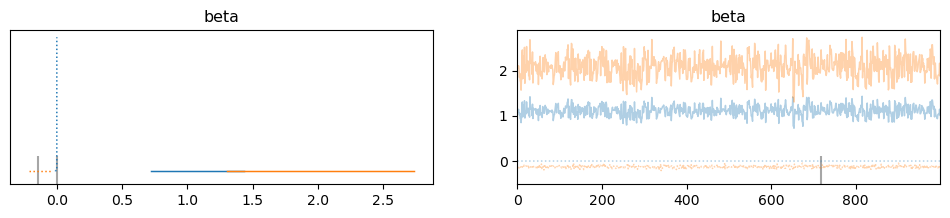

In [8]:
print(az.summary(spike_and_slab_idata))

az.plot_trace(spike_and_slab_idata, var_names = 'beta')

In [4]:
with pm.Model() as diffuse_regression:
    
    beta = pm.Normal('beta', mu=0, sigma=1/10, shape=(p, m)) # ridge penalty
    beta0 = pm.Normal('beta0', mu=0, sigma=10, shape = m)
    packed_L = pm.LKJCholeskyCov('packed_L', n = m, eta = 2.0, 
                                 sd_dist = pm.Exponential.dist(1.0, shape = m),
                                compute_corr = False)
    L = pm.expand_packed_triangular(m, packed_L)
    Sigma = pm.Deterministic('Sigma', L.dot(L.T))
    mu = pm.math.dot(X_stdized, beta)
    
    y_obs = pm.MvNormal('y_obs', mu=beta0 + mu, chol = L, observed=Y_stdized)

    diffuse_idata = pm.sample(1000, tune=1000, cores=1, target_accept=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [beta, beta0, packed_L]


/opt/conda/lib/python3.11/site-packages/pytensor/compile/function/types.py:970: RuntimeWarning: invalid value encountered in accumulate
  self.vm()


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 471 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Sigma[0, 0]   3.710  0.380   2.983    4.426      0.012    0.009    1036.0   
Sigma[0, 1]   7.418  0.760   5.985    8.862      0.024    0.019    1015.0   
Sigma[1, 0]   7.418  0.760   5.985    8.862      0.024    0.019    1015.0   
Sigma[1, 1]  14.942  1.527  12.116   17.911      0.048    0.037     998.0   
beta[0, 0]    0.160  0.044   0.080    0.247      0.001    0.001     932.0   
beta[0, 1]    0.180  0.087   0.023    0.339      0.003    0.002    1019.0   
beta0[0]     26.918  0.135  26.654   27.149      0.005    0.003     851.0   
beta0[1]     22.831  0.271  22.270   23.268      0.009    0.007     854.0   
packed_L[0]   1.924  0.098   1.727    2.104      0.003    0.002    1036.0   
packed_L[1]   3.846  0.198   3.469    4.221      0.006    0.005     998.0   
packed_L[2]   0.333  0.017   0.301    0.363      0.000    0.000    1845.0   

             ess_tail  r_hat  
Sigma[0, 0]    1082.0    1.0  
Sigma[0, 1]  

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

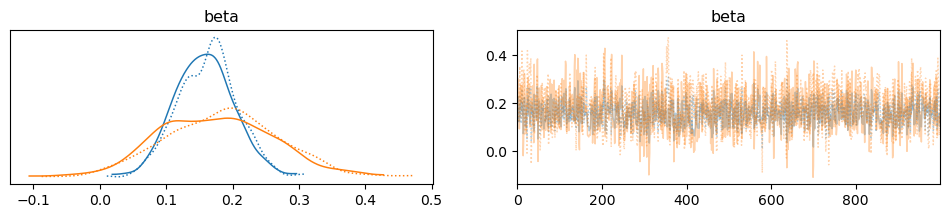

In [6]:
import arviz as az

print(az.summary(diffuse_idata))

az.plot_trace(diffuse_idata, var_names = 'beta')

From the above plots, we can see the results from L2-regularization are stable, while results from spike and slab are unstable. This may because spike and slab uses a Bernoulli Distribution for spike which makes LJK method on estimated covariance unstable. 

Spike-and-slab is similar to L2 regularization in the following three cases:

1. Gaussian Slab with Small Prior Variance

If the slab component of the spike-and-slab prior is a Gaussian with small variance, it resembles an L2 penalty.
This is because the posterior mode of a Bayesian model with a Gaussian prior on $\boldsymbol \beta$ behaves like ridge regression.

2. Continuous Relaxation of Spike-and-Slab

If instead of a point mass at zero, we use a strongly concentrated Gaussian (spike), it behaves like a strongly penalized ridge regression.

3. Large $\lambda$ in Ridge Regression

As $\lambda \rightarrow \infty$, ridge regression increasingly shrinks coefficients, similar to how spike-and-slab might exclude variables.

### Q3 Variable Selection

Perform multivarite regression (or multivariate probit classification) with the horseshoe variable selection prior and compare inference to analagous inference with spike and slab priors.

The horseshoe variable selection prior is introduced here
- https://www.pymc.io/projects/docs/en/v5.6.0/learn/core_notebooks/pymc_overview.html
- and searches for "horseshoe prior pymc" on google produce additional examples



### The Horseshoe prior

The [PyMC overview](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html) and [many](https://www.google.com/search?q=pymc+horseshoe&oq=pymc+horseshoe) other [resources](https://mellorjc.github.io/HorseshoePriorswithpymc3.html) provide ***Horseshoe prior*** [[1]](https://www.jstor.org/stable/25734098) [[2]](https://faculty.mccombs.utexas.edu/carlos.carvalho/Carvalhoetal2009.pdf) implementations 

| Half-Cauchy $\text{HC}_+(\xi)$ | Horseshoe Prior $\text{HSP}$ | Shrinkage $\kappa$ | Change of Variables|
|:-:|:-:|:-:|:-:|
|$$f(x \mid \xi) = \frac{2\cdot 1_{[x>=0]}(x)}{\pi \xi \left[1 + \left(\frac{x}{\xi}\right)^2\right]}$$|\begin{align*}w_i|\tau &\sim N(0, \sigma^{2}=\lambda_i^2\tau^2)\\\lambda_i &\sim HC_+(1)\\\tau &\sim HC_+(\tau_0)\end{align*}|\begin{align*}\kappa_{\lambda_i} ={}& 1/(1+\lambda_i^2)\\\lambda_i ={}& \sqrt{1/\kappa_{\lambda_i}-1}\\J_{\kappa_{\lambda_i}} ={}& \frac{1}{2}(\kappa_{\lambda_i}^{-1}-1)^{-\frac{1}{2}}\times \kappa_{\lambda_i}^{-2} \end{align*}|\begin{align*}f(\kappa_{\lambda_i}) = {} & f\left(\lambda_i = \sqrt{1/\kappa_{\lambda_i}-1}\right)\\ {} & \times \underbrace{\frac{1}{2}(\kappa_{\lambda_i}^{-1}-1)^{-\frac{1}{2}}\times \kappa_{\lambda_i}^{-2}}_{J_{\kappa_{\lambda_i}}} \end{align*}|



In [82]:
X = data[['motor_speed', 'torque']].values
Y = data[['pm', 'stator_tooth']].values

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
Y_mean, Y_std = Y.mean(axis=0), Y.std(axis=0)

X_stdized = (X - X_mean) / X_std
Y_stdized = (Y - Y_mean) / Y_std

N, D = X_stdized.shape
m = Y_stdized.shape[1]

D0 = 1

import pytensor.tensor as at

coords = {"predictors": np.arange(D), "outputs": np.arange(m)}

with pm.Model(coords=coords) as test_score_model:
    sigma = pm.HalfNormal("sigma", 25, dims="outputs")

    tau = pm.HalfStudentT("tau", 2, D0 / (D - D0) * sigma / np.sqrt(N), dims="outputs")
    tau_broadcasted = tau[None, :]  # Fix broadcasting

    lam = pm.HalfStudentT("lam", 2, dims="predictors")
    lam_broadcasted = lam[:, None]

    c2 = pm.InverseGamma("c2", 1, 0.1)

    z = pm.Normal("z", 0.0, 1.0, dims=("predictors", "outputs"))

    beta = pm.Deterministic(
        "beta",
        z * tau_broadcasted * lam_broadcasted * at.sqrt(c2 / (c2 + tau_broadcasted**2 * lam_broadcasted**2)),
        dims=("predictors", "outputs")
    )

    beta0 = pm.Normal("beta0", 100, 25.0, dims="outputs")

    mu = beta0 + at.dot(X_stdized, beta)

    scores = pm.Normal("scores", mu, sigma, observed=Y_stdized)

    idata = pm.sample(1000, tune=2000, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, tau, lam, c2, z, beta0]


Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 26 seconds.
There were 72 divergences after tuning. Increase `target_accept` or reparameterize.


             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0, 0]  0.340   0.227  -0.056    0.656      0.009    0.003     764.0   
beta[0, 1]  0.325   0.225  -0.056    0.660      0.009    0.003     659.0   
beta[1, 0]  0.192   0.223  -0.102    0.612      0.009    0.003     779.0   
beta[1, 1]  0.182   0.221  -0.115    0.607      0.009    0.003     606.0   
beta0[0]   -0.001   0.059  -0.108    0.115      0.001    0.001    2696.0   
beta0[1]    0.004   0.062  -0.113    0.122      0.002    0.001    1334.0   
c2          0.813   2.960   0.021    2.115      0.214    1.184     762.0   
lam[0]      5.492  11.823   0.001   16.234      0.238    3.110     595.0   
lam[1]      3.690  10.459   0.001   11.893      0.252    2.678     813.0   
sigma[0]    0.846   0.043   0.771    0.932      0.001    0.001    1456.0   
sigma[1]    0.864   0.044   0.784    0.950      0.001    0.001    2657.0   
tau[0]      0.190   0.615   0.010    0.419      0.014    0.180    1981.0   
tau[1]      

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

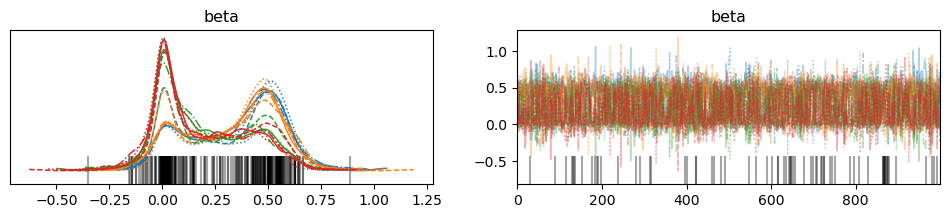

In [83]:
print(az.summary(idata))

az.plot_trace(idata, var_names = 'beta')

Similarity:

Both methods encourage many regression coefficients to be exactly or nearly zero.

Both use probabilistic priors to determine which variables should be included.

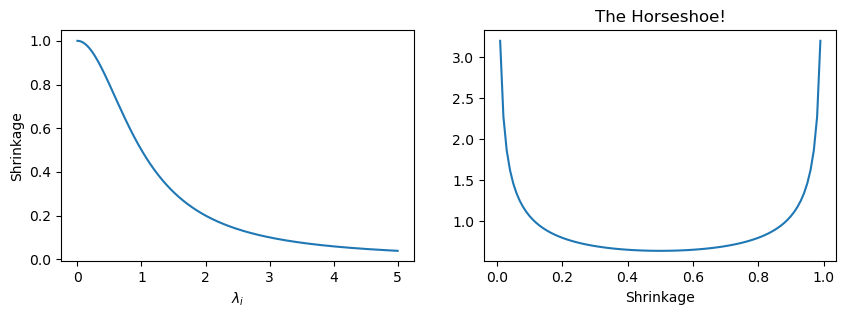

In [160]:
fig,ax = plt.subplots(1,2,figsize=(10,3))
support = np.linspace(0,5,1000)
# shrnk = trans(spprt) = 1/(1+sprt**2)
shrinkage = 1/(1+support**2)
ax[0].plot(support, shrinkage)
ax[0].set_ylabel("Shrinkage")
ax[0].set_xlabel("$\\lambda_i$") 
# change of variables: 
# spprt = (1/shrnk-1)**0.5; E.g., 1/(1+.5**2), (1/.8-1)**0.5;
# jacobian: .5(1/shrnk-1)**(-.5)*shrnk**(-2)
shrinkage = np.linspace(0.01,.99,99)
ax[1].plot(shrinkage, 
           stats.halfcauchy(scale=1).pdf((1/shrinkage-1)**0.5) * 
           .5*(1/shrinkage-1)**(-.5)*shrinkage**(-2))
ax[1].set_title('The Horseshoe!')
ax[1].set_xlabel("Shrinkage");